# Parte A – Frontiera Efficiente

In [16]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 11

TICKERS = {
    'Tech':       ['AAPL', 'MSFT', 'NVDA'],
    'Healthcare': ['JNJ',  'PFE',  'MRK'],
    'Energy':     ['XOM',  'CVX',  'BP'],
    'Index':      ['^GSPC'],
}
ALL_TICKERS = [t for group in TICKERS.values() for t in group]

START = '2015-01-01'
END   = '2025-01-01'  

print('Titoli selezionati:', ALL_TICKERS)
print(f'Periodo: {START} → {END}')

Titoli selezionati: ['AAPL', 'MSFT', 'NVDA', 'JNJ', 'PFE', 'MRK', 'XOM', 'CVX', 'BP', '^GSPC']
Periodo: 2015-01-01 → 2025-01-01


---
## Blocco 1 – Download prezzi mensili da Yahoo Finance

In [17]:
raw = yf.download(ALL_TICKERS, start=START, end=END, auto_adjust=True, progress=True)
prices = raw['Close'].resample('ME').last()

# Rinomina ^GSPC → SP500 per comodità nelle colonne
prices.columns = [c if c != '^GSPC' else 'SP500' for c in prices.columns]
prices.dropna(how='all', inplace=True)

print(f'\nOsservazioni mensili: {len(prices)}')
print(f'Periodo effettivo: {prices.index[0].date()} → {prices.index[-1].date()}')
prices.tail()

[*********************100%***********************]  10 of 10 completed


Osservazioni mensili: 120
Periodo effettivo: 2015-01-31 → 2024-12-31


,AAPL,BP,CVX,JNJ,MRK,MSFT,NVDA,PFE,XOM,SP500
Date,,,,,,,,,,
2024-08-31,227.296112,30.773748,137.353561,158.808426,111.671959,411.425995,119.312469,25.774496,111.334679,5648.399902
2024-09-30,231.266342,28.444876,136.722275,155.169968,107.778069,424.405701,121.391869,25.712301,110.655006,5762.479980
2024-10-31,224.229126,26.605339,138.161255,153.063522,97.110352,400.783813,132.707382,25.143681,110.239647,5705.450195
2024-11-30,235.823303,26.987698,151.865814,149.610611,96.464973,418.495422,138.195206,23.648483,112.268562,6032.379883
2024-12-31,248.830215,27.217892,135.837967,139.582504,95.170738,416.558380,134.246017,23.937208,102.379868,5881.629883


---
## Blocco 2 – Rendimenti logaritmici mensili


In [18]:
returns = np.log(prices / prices.shift(1)).dropna()

print(f'Osservazioni di rendimento: {len(returns)}')
returns.head()

Osservazioni di rendimento: 119


,AAPL,BP,CVX,JNJ,MRK,MSFT,NVDA,PFE,XOM,SP500
Date,,,,,,,,,,
2015-02-28,0.096016,0.079705,0.049455,0.030366,-0.029290,0.089036,0.142699,0.102492,0.020230,0.053439
2015-03-31,-0.031874,-0.057868,-0.016063,-0.018808,-0.010214,-0.075530,-0.052583,0.013602,-0.040804,-0.017549
2015-04-30,0.005770,0.098536,0.056300,-0.014014,0.035547,0.179202,0.058909,-0.025030,0.027501,0.008485
2015-05-31,0.044341,-0.026166,-0.065426,0.016697,0.022085,-0.030804,0.001460,0.032120,-0.016913,0.010437
2015-06-30,-0.037938,-0.036850,-0.065497,-0.027127,-0.059669,-0.059572,-0.095717,-0.035739,-0.023754,-0.021236


---
## Blocco 3 – Statistiche descrittive (annualizzate)


In [19]:
ann = 12  # fattore di annualizzazione

mean_returns = returns.mean()
std_returns  = returns.std()

summary = pd.DataFrame({
    'Rend. mensile (%)':  (mean_returns * 100).round(3),
    'Rend. annuo (%)':    (mean_returns * ann * 100).round(2),
    'Std Dev mensile (%)': (std_returns * 100).round(3),
    'Std Dev annua (%)':  (std_returns * np.sqrt(ann) * 100).round(2),
    'Sharpe (rf=0)':      ((mean_returns * ann) / (std_returns * np.sqrt(ann))).round(3),
})

display(summary)

,Rend. mensile (%),Rend. annuo (%),Std Dev mensile (%),Std Dev annua (%),Sharpe (rf=0)
AAPL,1.900,22.81,7.886,27.32,0.835
BP,0.266,3.19,7.347,25.45,0.125
CVX,0.649,7.79,7.728,26.77,0.291
JNJ,0.541,6.49,4.531,15.70,0.413
MRK,0.717,8.60,5.606,19.42,0.443
MSFT,2.099,25.18,6.034,20.90,1.205
NVDA,4.769,57.22,13.135,45.50,1.258
PFE,0.238,2.85,6.534,22.64,0.126
XOM,0.540,6.49,7.793,27.00,0.240
SP500,0.909,10.90,4.437,15.37,0.709


---
## Blocco 4 – Matrice di varianza-covarianza

In [20]:
cov_matrix = returns.cov()

# Stampa la matrice moltiplicata per 100 per migliorare la leggibilità
print('Matrice di Varianza-Covarianza (mensile, ×100):')
display((cov_matrix * 100).round(4))

Matrice di Varianza-Covarianza (mensile, ×100):


,AAPL,BP,CVX,JNJ,MRK,MSFT,NVDA,PFE,XOM,SP500
AAPL,0.6219,0.0961,0.1295,0.1225,0.0447,0.2939,0.5780,0.1255,0.1240,0.2391
BP,0.0961,0.5398,0.3960,0.0865,0.1315,0.0925,0.1206,0.0469,0.4420,0.1386
CVX,0.1295,0.3960,0.5972,0.1370,0.1520,0.1282,0.2068,0.1497,0.5194,0.2106
JNJ,0.1225,0.0865,0.1370,0.2053,0.1063,0.0952,0.0684,0.1609,0.1368,0.1104
MRK,0.0447,0.1315,0.1520,0.1063,0.3143,0.0831,0.0275,0.0865,0.1536,0.0840
MSFT,0.2939,0.0925,0.1282,0.0952,0.0831,0.3641,0.4704,0.0876,0.0953,0.1887
NVDA,0.5780,0.1206,0.2068,0.0684,0.0275,0.4704,1.7254,0.1432,0.1687,0.3495
PFE,0.1255,0.0469,0.1497,0.1609,0.0865,0.0876,0.1432,0.4270,0.0817,0.1244
XOM,0.1240,0.4420,0.5194,0.1368,0.1536,0.0953,0.1687,0.0817,0.6073,0.1886
SP500,0.2391,0.1386,0.2106,0.1104,0.0840,0.1887,0.3495,0.1244,0.1886,0.1969


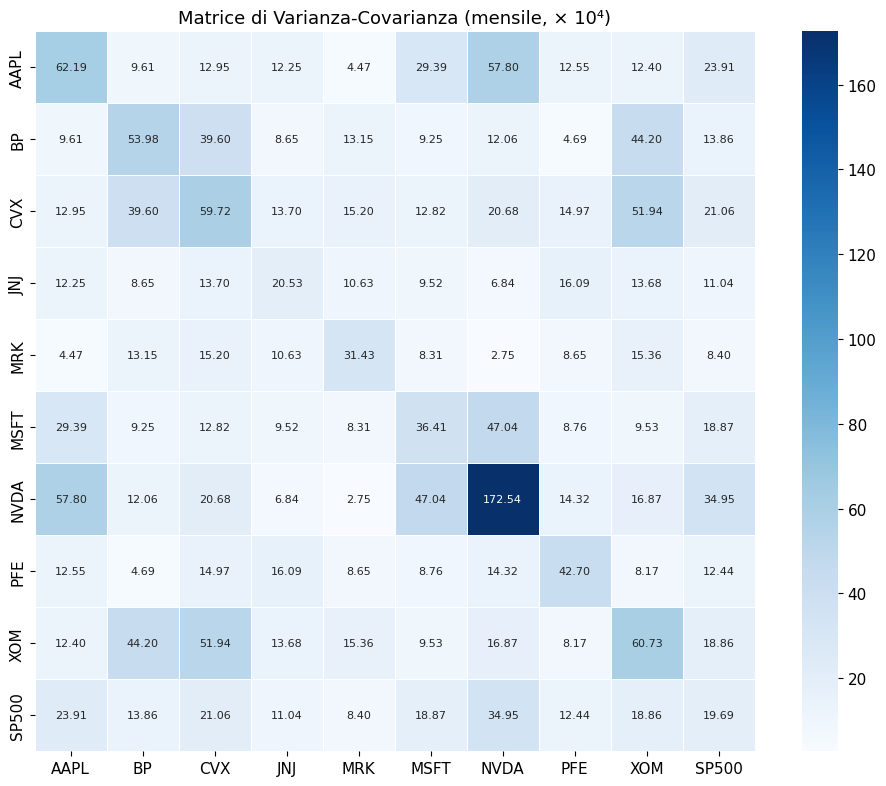

Heatmap salvata: covariance_heatmap.png


In [21]:
# Heatmap della matrice di covarianza
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cov_matrix * 10000,    # × 10000 per visualizzare in unità di (%)²
    annot=True, fmt='.2f', cmap='Blues',
    square=True, linewidths=0.5, ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Matrice di Varianza-Covarianza (mensile, × 10⁴)', fontsize=13)
fig.tight_layout()
fig.savefig('covariance_heatmap.png', dpi=150)
plt.show()
print('Heatmap salvata: covariance_heatmap.png')

---
## Blocco 5 – Matrice di correlazione

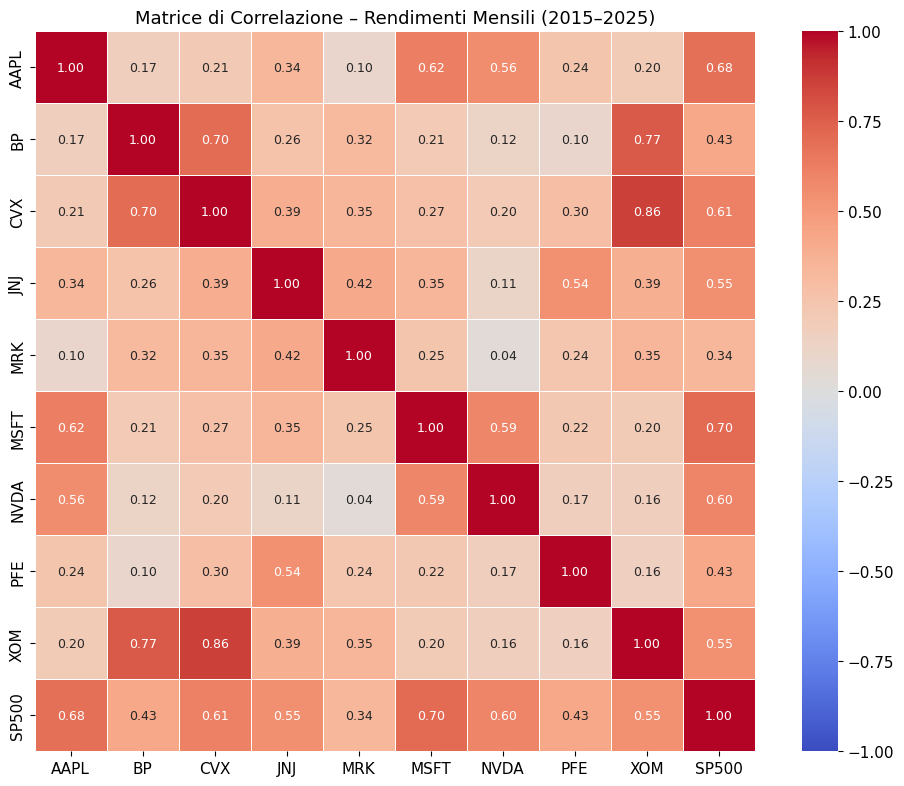

Heatmap salvata: correlation_heatmap.png


In [22]:
corr_matrix = returns.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=ax,
    annot_kws={'size': 9}
)
ax.set_title('Matrice di Correlazione – Rendimenti Mensili (2015–2025)', fontsize=13)
fig.tight_layout()
fig.savefig('correlation_heatmap.png', dpi=150)
plt.show()
print('Heatmap salvata: correlation_heatmap.png')

---
## Blocco 6 – Grafico rendimento atteso vs rischio (scatter)

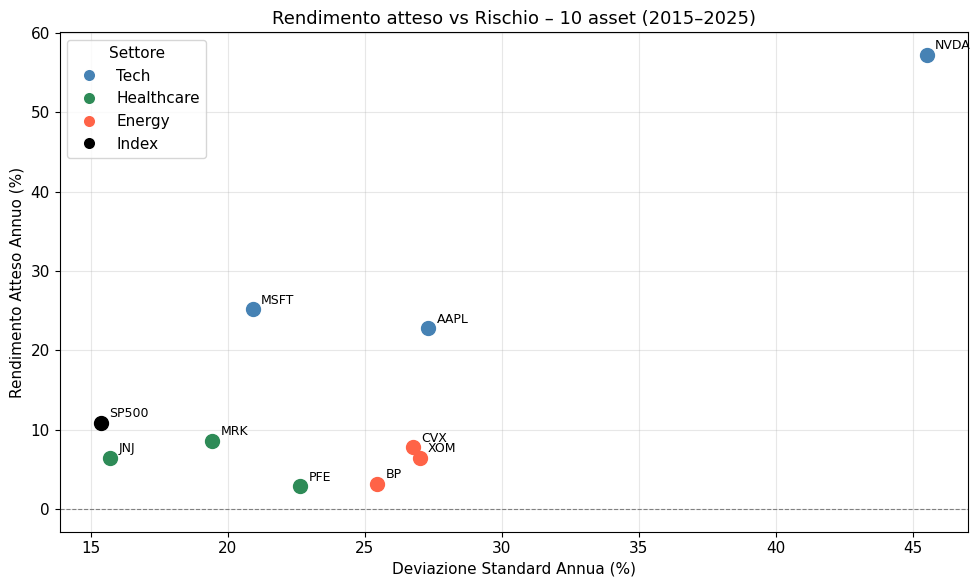

In [23]:
# Colori per settore
sector_colors = {}
palette = {'Tech': 'steelblue', 'Healthcare': 'seagreen', 'Energy': 'tomato', 'Index': 'black'}
for sector, tickers in TICKERS.items():
    for t in tickers:
        name = 'SP500' if t == '^GSPC' else t
        sector_colors[name] = palette[sector]

mu_ann    = mean_returns * ann * 100          
sigma_ann = std_returns * np.sqrt(ann) * 100  

fig, ax = plt.subplots(figsize=(10, 6))
for ticker in returns.columns:
    ax.scatter(sigma_ann[ticker], mu_ann[ticker],
               color=sector_colors[ticker], s=100, zorder=3)
    ax.annotate(ticker, (sigma_ann[ticker], mu_ann[ticker]),
                textcoords='offset points', xytext=(6, 4), fontsize=9)

# Legenda manuale per settore
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=9, label=s)
                   for s, c in palette.items()]
ax.legend(handles=legend_elements, title='Settore', loc='upper left')

ax.set_xlabel('Deviazione Standard Annua (%)')
ax.set_ylabel('Rendimento Atteso Annuo (%)')
ax.set_title('Rendimento atteso vs Rischio – 10 asset (2015–2025)', fontsize=13)
ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig('risk_return_scatter.png', dpi=150)
plt.show()

---
## Blocco 7 – Selezione dei 5 titoli e frontiera efficiente analitica (Punto 2)

### Selezione dei 5 titoli

Si scelgono: **NVDA, MSFT, JNJ, MRK, XOM**

| Ticker | Settore |
|---|---|
| NVDA | Tech |  
| MSFT | Tech |  
| JNJ | Healthcare |  
| MRK | Healthcare |  
| XOM | Energy | 

In [24]:
# ── Dati per i 5 titoli selezionati 
SELECTED = ['NVDA', 'MSFT', 'JNJ', 'MRK', 'XOM']
n5 = len(SELECTED)
ret5  = returns[SELECTED]
mu5   = ret5.mean().values          
Sig5  = ret5.cov().values           
iota  = np.ones(n5)

print("Rendimenti mensili selezionati (%):")
for t, m in zip(SELECTED, mu5):
    print(f"  {t:6s}: {m*100:.3f}%")

print("\nMatrice di correlazione dei 5 titoli selezionati:")
display(ret5.corr().round(3))

# ── Scalari di Markowitz 
Sig5_inv = np.linalg.inv(Sig5)

A_mk = float(iota @ Sig5_inv @ iota)      
B_mk = float(iota @ Sig5_inv @ mu5)       
C_mk = float(mu5  @ Sig5_inv @ mu5)       
D_mk = A_mk * C_mk - B_mk**2              

print(f"\nScalari di Markowitz:")
print(f"  A = {A_mk:.4f}")
print(f"  B = {B_mk:.4f}")
print(f"  C = {C_mk:.4f}")
print(f"  D = {D_mk:.6f}")

# ── GMV portfolio 
w_gmv   = Sig5_inv @ iota / A_mk
mu_gmv  = B_mk / A_mk
sig_gmv = np.sqrt(1.0 / A_mk)

print(f"\nGlobal Minimum Variance (GMV):")
print(f"  Rendimento mensile : {mu_gmv*100:.4f}%  →  annuo: {mu_gmv*12*100:.2f}%")
print(f"  Std Dev mensile    : {sig_gmv*100:.4f}%  →  annua: {sig_gmv*np.sqrt(12)*100:.2f}%")
print(f"  Pesi:")
for t, w in zip(SELECTED, w_gmv):
    print(f"    {t:6s}: {w:+.4f}")

Rendimenti mensili selezionati (%):
  NVDA  : 4.769%
  MSFT  : 2.099%
  JNJ   : 0.541%
  MRK   : 0.717%
  XOM   : 0.540%

Matrice di correlazione dei 5 titoli selezionati:


,NVDA,MSFT,JNJ,MRK,XOM
NVDA,1.000,0.593,0.115,0.037,0.165
MSFT,0.593,1.000,0.348,0.246,0.203
JNJ,0.115,0.348,1.000,0.418,0.387
MRK,0.037,0.246,0.418,1.000,0.351
XOM,0.165,0.203,0.387,0.351,1.000



Scalari di Markowitz:
  A = 652.3700
  B = 6.0954
  C = 0.1654
  D = 70.759225

Global Minimum Variance (GMV):
  Rendimento mensile : 0.9344%  →  annuo: 11.21%
  Std Dev mensile    : 3.9152%  →  annua: 13.56%
  Pesi:
    NVDA  : -0.0011
    MSFT  : +0.2284
    JNJ   : +0.4856
    MRK   : +0.2404
    XOM   : +0.0467


Frontiera numerica: 50 punti calcolati
Verifica convergenza: tutti i punti risolti = True


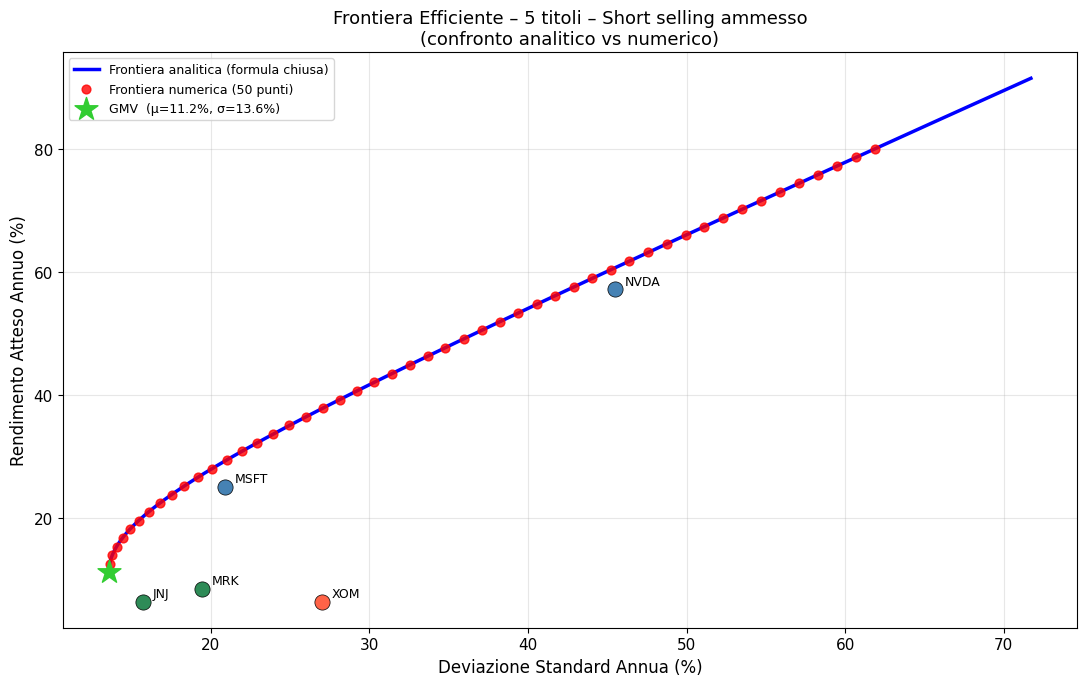

I punti numerici devono coincidere con la curva analitica → verifica coerenza ✓


In [25]:
mu_grid = np.linspace(mu_gmv, mu5.max() * 1.6, 300)
sig_analytical = np.sqrt((A_mk * mu_grid**2 - 2*B_mk * mu_grid + C_mk) / D_mk)

def weights_analytical(mu_p):
    lam = (A_mk * mu_p - B_mk) / D_mk
    gam = (C_mk - B_mk * mu_p) / D_mk
    return lam * (Sig5_inv @ mu5) + gam * (Sig5_inv @ iota)

from scipy.optimize import minimize

def portfolio_vol(w):
    return np.sqrt(w @ Sig5 @ w)

mu_targets = np.linspace(mu_gmv, mu5.max() * 1.4, 50)
sig_numerical = np.zeros(len(mu_targets))
w_numerical   = np.zeros((len(mu_targets), n5))

for i, mu_t in enumerate(mu_targets):
    constraints = [
        {'type': 'eq', 'fun': lambda w, mt=mu_t: w @ mu5 - mt},  # rendimento target
        {'type': 'eq', 'fun': lambda w: w.sum() - 1}              # pesi sommano a 1
    ]
    res = minimize(portfolio_vol, x0=np.ones(n5)/n5,
                   method='SLSQP', constraints=constraints,
                   options={'ftol': 1e-12, 'maxiter': 1000})
    sig_numerical[i]   = res.fun
    w_numerical[i]     = res.x

print(f"Frontiera numerica: {len(mu_targets)} punti calcolati")
print(f"Verifica convergenza: tutti i punti risolti = {np.all(sig_numerical > 0)}")

# ── Grafico confronto analitica vs numerica 
fig, ax = plt.subplots(figsize=(11, 7))

# Frontiera analitica (curva continua)
ax.plot(sig_analytical * np.sqrt(12) * 100,
        mu_grid * 12 * 100,
        'b-', linewidth=2.5, label='Frontiera analitica (formula chiusa)', zorder=2)

# Frontiera numerica (punti, devono sovrapporsi alla curva analitica)
ax.scatter(sig_numerical * np.sqrt(12) * 100,
           mu_targets * 12 * 100,
           color='red', s=40, zorder=5, label='Frontiera numerica (50 punti)', alpha=0.8)

# GMV
ax.scatter(sig_gmv * np.sqrt(12) * 100, mu_gmv * 12 * 100,
           color='limegreen', s=300, zorder=6, marker='*',
           label=f'GMV  (μ={mu_gmv*12*100:.1f}%, σ={sig_gmv*np.sqrt(12)*100:.1f}%)')

# Singoli asset
colors5 = {'NVDA': 'steelblue', 'MSFT': 'steelblue',
           'JNJ': 'seagreen', 'MRK': 'seagreen', 'XOM': 'tomato'}
for t in SELECTED:
    ax.scatter(ret5[t].std() * np.sqrt(12) * 100,
               ret5[t].mean() * 12 * 100,
               color=colors5[t], s=120, zorder=4, edgecolors='black', linewidths=0.5)
    ax.annotate(t, (ret5[t].std()*np.sqrt(12)*100, ret5[t].mean()*12*100),
                textcoords='offset points', xytext=(7, 3), fontsize=9)

ax.set_xlabel('Deviazione Standard Annua (%)', fontsize=12)
ax.set_ylabel('Rendimento Atteso Annuo (%)', fontsize=12)
ax.set_title('Frontiera Efficiente – 5 titoli – Short selling ammesso\n(confronto analitico vs numerico)', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig('efficient_frontier_A2.png', dpi=150)
plt.show()
print("I punti numerici devono coincidere con la curva analitica → verifica coerenza ✓")

---
## Blocco 8 – Frontiera efficiente senza short selling (Punto 3)

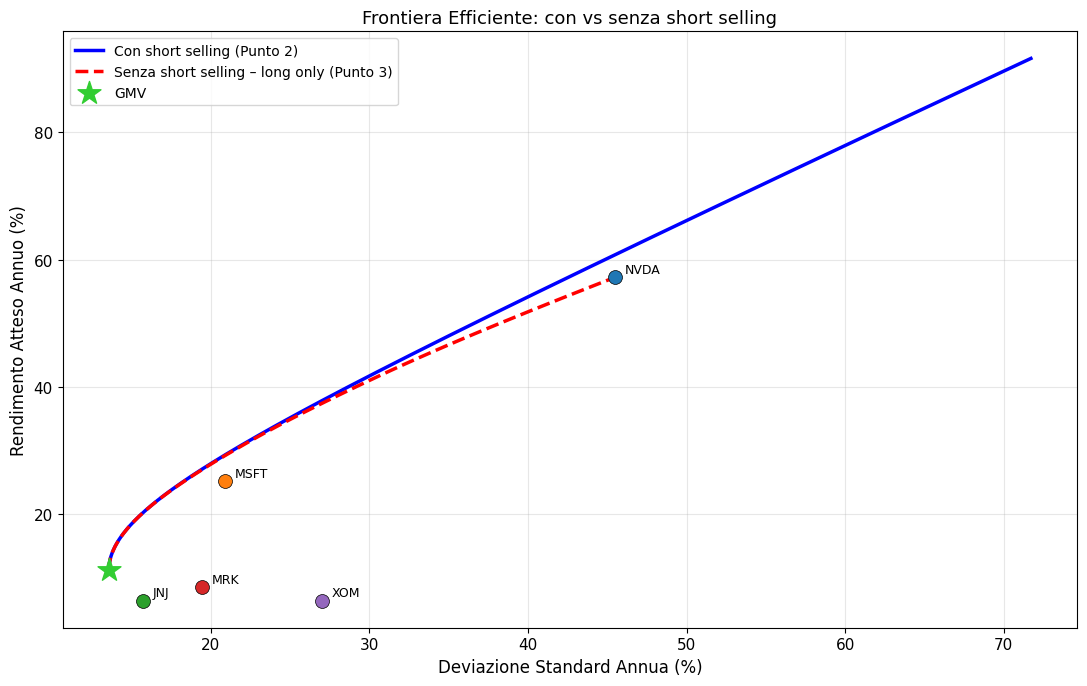

Commento:
La frontiera long-only è all'interno (destra) di quella con short selling.
Il vincolo w≥0 riduce le possibilità di investimento → a parità di rischio,
il rendimento massimo raggiungibile è inferiore.


In [26]:
bounds_long = [(0, None)] * n5

mu_targets_lo = np.linspace(mu_gmv, mu5.max() * 1.01, 50)
sig_long_only = []
mu_long_only  = []

for mu_t in mu_targets_lo:
    constraints = [
        {'type': 'eq', 'fun': lambda w, mt=mu_t: w @ mu5 - mt},
        {'type': 'eq', 'fun': lambda w: w.sum() - 1}
    ]
    res = minimize(portfolio_vol, x0=np.ones(n5)/n5,
                   method='SLSQP', constraints=constraints,
                   bounds=bounds_long,
                   options={'ftol': 1e-12, 'maxiter': 1000})
    if res.success:
        sig_long_only.append(res.fun)
        mu_long_only.append(mu_t)

sig_long_only = np.array(sig_long_only)
mu_long_only  = np.array(mu_long_only)

# ── Grafico confronto: con/senza short selling 
fig, ax = plt.subplots(figsize=(11, 7))

ax.plot(sig_analytical * np.sqrt(12) * 100,
        mu_grid * 12 * 100,
        'b-', linewidth=2.5, label='Con short selling (Punto 2)', zorder=2)

ax.plot(sig_long_only * np.sqrt(12) * 100,
        mu_long_only * 12 * 100,
        'r--', linewidth=2.5, label='Senza short selling – long only (Punto 3)', zorder=3)

ax.scatter(sig_gmv * np.sqrt(12) * 100, mu_gmv * 12 * 100,
           color='limegreen', s=300, zorder=6, marker='*', label='GMV')

for t in SELECTED:
    ax.scatter(ret5[t].std()*np.sqrt(12)*100, ret5[t].mean()*12*100,
               s=100, zorder=4, edgecolors='black', linewidths=0.5)
    ax.annotate(t, (ret5[t].std()*np.sqrt(12)*100, ret5[t].mean()*12*100),
                textcoords='offset points', xytext=(7, 3), fontsize=9)

ax.set_xlabel('Deviazione Standard Annua (%)', fontsize=12)
ax.set_ylabel('Rendimento Atteso Annuo (%)', fontsize=12)
ax.set_title('Frontiera Efficiente: con vs senza short selling', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig('efficient_frontier_A3_comparison.png', dpi=150)
plt.show()

print("Commento:")
print("La frontiera long-only è all'interno (destra) di quella con short selling.")
print("Il vincolo w≥0 riduce le possibilità di investimento → a parità di rischio,")
print("il rendimento massimo raggiungibile è inferiore.")

---
## Blocco 9 – Portafoglio di mercato (Punto 4)

S&P 500 (proxy portafoglio di mercato):
  Rendimento atteso mensile  : 0.909%  →  annuo: 10.90%
  Std Dev mensile            : 4.437%  →  annua: 15.37%

Frontiera (stesso rischio σ=15.37%):
  Rendimento frontiera annuo : 19.47%
  Rendimento SP500 annuo     : 10.90%
  Differenza (alpha)         : 8.56% / anno

Conclusion: SP500 NON è sulla frontiera efficiente.


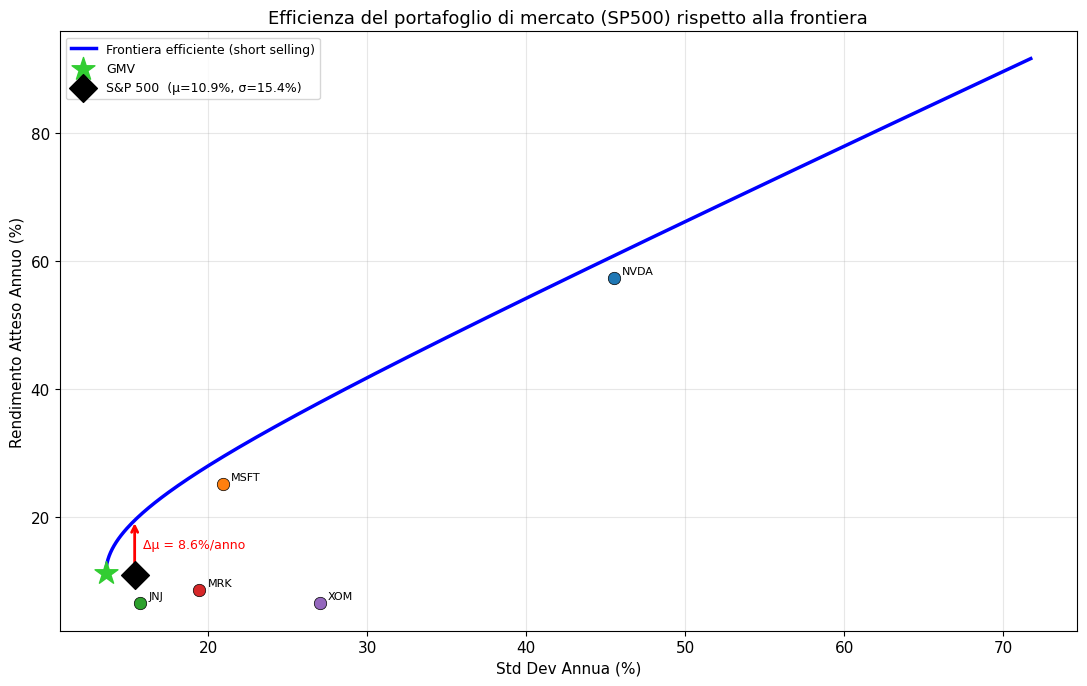

In [27]:
mu_mkt  = returns['SP500'].mean()
sig_mkt = returns['SP500'].std()

# Rendimento sulla frontiera a parità di σ_mkt
sig_mkt_ann = sig_mkt * np.sqrt(12)
coeff = [A_mk,
         -2 * B_mk,
         C_mk - D_mk * sig_mkt**2]
mu_frontier_at_mkt_risk = max(np.roots(coeff))  

print(f"S&P 500 (proxy portafoglio di mercato):")
print(f"  Rendimento atteso mensile  : {mu_mkt*100:.3f}%  →  annuo: {mu_mkt*12*100:.2f}%")
print(f"  Std Dev mensile            : {sig_mkt*100:.3f}%  →  annua: {sig_mkt_ann*100:.2f}%")
print(f"\nFrontiera (stesso rischio σ={sig_mkt_ann*100:.2f}%):")
print(f"  Rendimento frontiera annuo : {mu_frontier_at_mkt_risk*12*100:.2f}%")
print(f"  Rendimento SP500 annuo     : {mu_mkt*12*100:.2f}%")
print(f"  Differenza (alpha)         : {(mu_frontier_at_mkt_risk - mu_mkt)*12*100:.2f}% / anno")
print(f"\nConclusion: SP500 {'è' if abs((mu_frontier_at_mkt_risk - mu_mkt)*12) < 0.005 else 'NON è'} sulla frontiera efficiente.")

fig, ax = plt.subplots(figsize=(11, 7))
ax.plot(sig_analytical*np.sqrt(12)*100, mu_grid*12*100,
        'b-', linewidth=2.5, label='Frontiera efficiente (short selling)')
ax.scatter(sig_gmv*np.sqrt(12)*100, mu_gmv*12*100,
           color='limegreen', s=300, marker='*', zorder=6, label='GMV')
ax.scatter(sig_mkt*np.sqrt(12)*100, mu_mkt*12*100,
           color='black', s=200, marker='D', zorder=7,
           label=f'S&P 500  (μ={mu_mkt*12*100:.1f}%, σ={sig_mkt_ann*100:.1f}%)')
# Freccia che indica quanto manca alla frontiera
ax.annotate('', xy=(sig_mkt*np.sqrt(12)*100, mu_frontier_at_mkt_risk*12*100),
            xytext=(sig_mkt*np.sqrt(12)*100, mu_mkt*12*100),
            arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax.text(sig_mkt*np.sqrt(12)*100 + 0.5, (mu_mkt + mu_frontier_at_mkt_risk)/2*12*100,
        f'Δμ = {(mu_frontier_at_mkt_risk-mu_mkt)*12*100:.1f}%/anno',
        color='red', fontsize=9)
for t in SELECTED:
    ax.scatter(ret5[t].std()*np.sqrt(12)*100, ret5[t].mean()*12*100,
               s=80, zorder=4, edgecolors='black', linewidths=0.5)
    ax.annotate(t, (ret5[t].std()*np.sqrt(12)*100, ret5[t].mean()*12*100),
                textcoords='offset points', xytext=(6, 3), fontsize=8)
ax.set_xlabel('Std Dev Annua (%)'); ax.set_ylabel('Rendimento Atteso Annuo (%)')
ax.set_title('Efficienza del portafoglio di mercato (SP500) rispetto alla frontiera', fontsize=13)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig('market_portfolio_A4.png', dpi=150)
plt.show()

---
## Blocco 10 – GMV, EW5, EW10 (Punto 5)

Confronto portafogli con la frontiera efficiente (annualizzato):



,Rend. atteso annuo (%),Std Dev annua (%),Rend. frontiera stesso σ (%),Rendimento perso (%)
Portafoglio,,,,
GMV,11.21,13.56,NaN,NaN
EW5,20.80,17.01,22.92,2.12
EW10,15.15,15.89,20.66,5.51
S&P 500,10.90,15.37,19.47,8.56



Note:
'Rendimento perso' = quanto rendimento si lascia sul tavolo rispetto al
portafoglio efficiente con la stessa std dev. GMV ≈ 0 per costruzione.


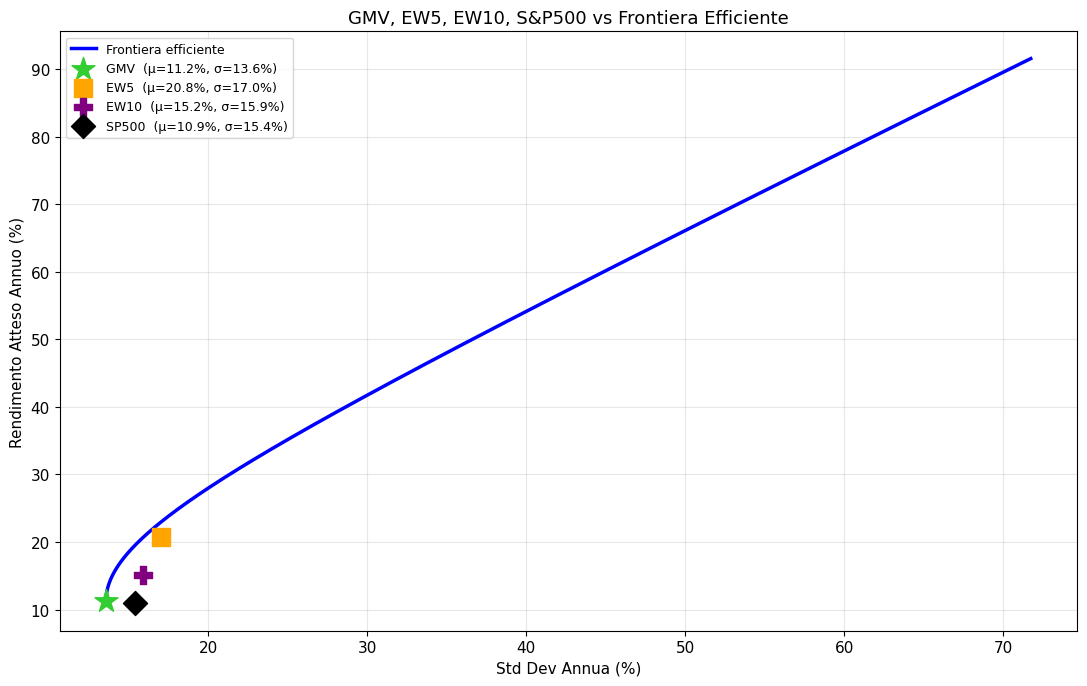

In [28]:
ann = 12

# ── EW5 
w_ew5   = np.ones(n5) / n5
mu_ew5  = w_ew5 @ mu5
sig_ew5 = np.sqrt(w_ew5 @ Sig5 @ w_ew5)

# ── EW10 
mu10  = returns.mean().values
Sig10 = returns.cov().values
n10   = len(returns.columns)
w_ew10   = np.ones(n10) / n10
mu_ew10  = w_ew10 @ mu10
sig_ew10 = np.sqrt(w_ew10 @ Sig10 @ w_ew10)

# ── Funzione: rendimento frontiera allo stesso rischio 
def mu_on_frontier_given_sigma(sigma_p):
    """Restituisce il rendimento efficiente alla std dev mensile sigma_p."""
    c_quad = [A_mk, -2*B_mk, C_mk - D_mk * sigma_p**2]
    roots = np.roots(c_quad)
    real_roots = roots[np.isreal(roots)].real
    if len(real_roots) == 0:
        return np.nan
    return float(np.max(real_roots))   # parte superiore (efficiente)

mu_front_gmv  = mu_on_frontier_given_sigma(sig_gmv)
mu_front_ew5  = mu_on_frontier_given_sigma(sig_ew5)
mu_front_ew10 = mu_on_frontier_given_sigma(sig_ew10)
mu_front_mkt  = mu_on_frontier_given_sigma(sig_mkt)

# ── Tabella riassuntiva 
summary = pd.DataFrame({
    'Portafoglio':      ['GMV', 'EW5', 'EW10', 'S&P 500'],
    'Rend. atteso annuo (%)':   [x*ann*100 for x in [mu_gmv, mu_ew5, mu_ew10, mu_mkt]],
    'Std Dev annua (%)':        [x*np.sqrt(ann)*100 for x in [sig_gmv, sig_ew5, sig_ew10, sig_mkt]],
    'Rend. frontiera stesso σ (%)': [x*ann*100 for x in [mu_front_gmv, mu_front_ew5, mu_front_ew10, mu_front_mkt]],
    'Rendimento perso (%)':     [(f - a)*ann*100 for f, a in
                                 zip([mu_front_gmv, mu_front_ew5, mu_front_ew10, mu_front_mkt],
                                     [mu_gmv, mu_ew5, mu_ew10, mu_mkt])],
}).set_index('Portafoglio').round(2)

print("Confronto portafogli con la frontiera efficiente (annualizzato):\n")
display(summary)
print("\nNote:")
print("'Rendimento perso' = quanto rendimento si lascia sul tavolo rispetto al")
print("portafoglio efficiente con la stessa std dev. GMV ≈ 0 per costruzione.")

# ── Grafico 
fig, ax = plt.subplots(figsize=(11, 7))
ax.plot(sig_analytical*np.sqrt(ann)*100, mu_grid*ann*100, 'b-', lw=2.5, label='Frontiera efficiente')

benchmarks = {
    'GMV':    (sig_gmv,  mu_gmv,  'limegreen', '*', 300),
    'EW5':    (sig_ew5,  mu_ew5,  'orange',    's', 150),
    'EW10':   (sig_ew10, mu_ew10, 'purple',    'P', 150),
    'SP500':  (sig_mkt,  mu_mkt,  'black',     'D', 150),
}
for name, (s, m, c, mk, sz) in benchmarks.items():
    ax.scatter(s*np.sqrt(ann)*100, m*ann*100, color=c, s=sz, marker=mk, zorder=6,
               label=f'{name}  (μ={m*ann*100:.1f}%, σ={s*np.sqrt(ann)*100:.1f}%)')

ax.set_xlabel('Std Dev Annua (%)'); ax.set_ylabel('Rendimento Atteso Annuo (%)')
ax.set_title('GMV, EW5, EW10, S&P500 vs Frontiera Efficiente', fontsize=13)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig('benchmarks_A5.png', dpi=150)
plt.show()

---
## Blocco 11 – Tasso risk-free e portafoglio di tangenza (Punto 6)

Tasso risk-free: 2.00% annuo  (0.1667% mensile)

Portafoglio di Tangenza:
  Rendimento atteso mensile  : 3.1001%  →  annuo: 37.20%
  Std Dev mensile            : 7.6533%  →  annua: 26.51%
  Sharpe Ratio (mensile)     : 0.3833  →  annuo: 1.3278

  Pesi portafoglio di tangenza:
    NVDA  : +0.3960
    MSFT  : +0.5395
    JNJ   : -0.0695
    MRK   : +0.2544
    XOM   : -0.1204

  Verifica: somma pesi = 1.000000


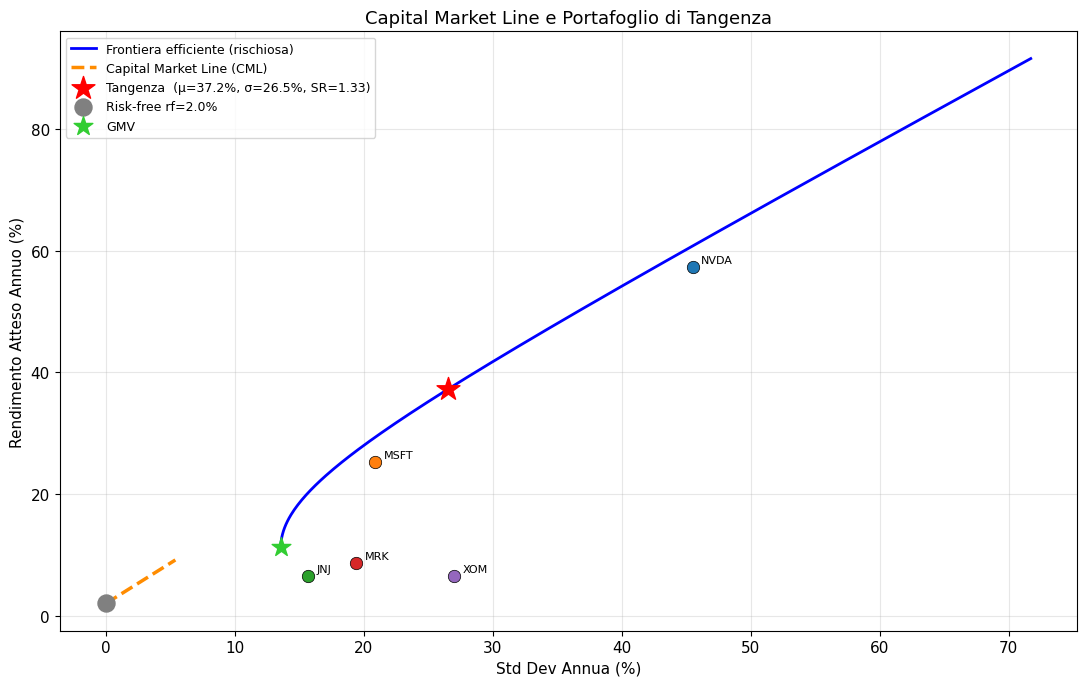

In [29]:
# ── Tasso risk-free (modificabile) ────────────────────────────────────────────
rf_annual = 0.02          # 2% annuo – BOT 3 mesi media 2015-2025
rf = rf_annual / ann      # mensile: 0.1667%

# ── Portafoglio di tangenza ────────────────────────────────────────────────────
mu_excess = mu5 - rf
z = Sig5_inv @ mu_excess
w_tan = z / (iota @ z)

mu_tan  = w_tan @ mu5
sig_tan = np.sqrt(w_tan @ Sig5 @ w_tan)
sr_tan  = (mu_tan - rf) / sig_tan          # Sharpe ratio mensile

print(f"Tasso risk-free: {rf_annual*100:.2f}% annuo  ({rf*100:.4f}% mensile)\n")
print("Portafoglio di Tangenza:")
print(f"  Rendimento atteso mensile  : {mu_tan*100:.4f}%  →  annuo: {mu_tan*ann*100:.2f}%")
print(f"  Std Dev mensile            : {sig_tan*100:.4f}%  →  annua: {sig_tan*np.sqrt(ann)*100:.2f}%")
print(f"  Sharpe Ratio (mensile)     : {sr_tan:.4f}  →  annuo: {sr_tan*np.sqrt(ann):.4f}")
print(f"\n  Pesi portafoglio di tangenza:")
for t, w in zip(SELECTED, w_tan):
    print(f"    {t:6s}: {w:+.4f}")
print(f"\n  Verifica: somma pesi = {w_tan.sum():.6f}")

# ── Capital Market Line (CML) 
sig_cml = np.linspace(0, mu5.max()*1.5 / (sr_tan * np.sqrt(ann)) / np.sqrt(ann), 200)
mu_cml  = rf + sr_tan * sig_cml

fig, ax = plt.subplots(figsize=(11, 7))

# Frontiera rischiosa
ax.plot(sig_analytical*np.sqrt(ann)*100, mu_grid*ann*100,
        'b-', lw=2, label='Frontiera efficiente (rischiosa)', zorder=2)

# CML
ax.plot(sig_cml*np.sqrt(ann)*100, mu_cml*ann*100,
        'darkorange', lw=2.5, linestyle='--', label='Capital Market Line (CML)', zorder=3)

# Tangenza
ax.scatter(sig_tan*np.sqrt(ann)*100, mu_tan*ann*100,
           color='red', s=300, marker='*', zorder=7,
           label=f'Tangenza  (μ={mu_tan*ann*100:.1f}%, σ={sig_tan*np.sqrt(ann)*100:.1f}%, SR={sr_tan*np.sqrt(ann):.2f})')

# rf
ax.scatter(0, rf_annual*100, color='grey', s=150, marker='o', zorder=6, label=f'Risk-free rf={rf_annual*100:.1f}%')

# GMV
ax.scatter(sig_gmv*np.sqrt(ann)*100, mu_gmv*ann*100,
           color='limegreen', s=200, marker='*', zorder=6, label='GMV')

for t in SELECTED:
    ax.scatter(ret5[t].std()*np.sqrt(ann)*100, ret5[t].mean()*ann*100,
               s=80, zorder=4, edgecolors='black', lw=0.5)
    ax.annotate(t, (ret5[t].std()*np.sqrt(ann)*100, ret5[t].mean()*ann*100),
                textcoords='offset points', xytext=(6, 3), fontsize=8)

ax.set_xlabel('Std Dev Annua (%)'); ax.set_ylabel('Rendimento Atteso Annuo (%)')
ax.set_title('Capital Market Line e Portafoglio di Tangenza', fontsize=13)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig('tangency_CML_A6.png', dpi=150)
plt.show()

---
## Blocco 12 – Portafoglio ottimo con avversione al rischio A (Punto 7)

Avversione al rischio A = 3.0

Frazione ottima nel portafoglio rischioso: y* = 1.6694
  → y* > 1: l'investitore usa LEVA (prende a prestito al tasso rf)

Portafoglio ottimo:
  Rendimento atteso mensile  : 5.0637%  →  annuo: 60.76%
  Std Dev mensile            : 12.7764%  →  annua: 44.26%
  Utilità (mensile)          : 2.6152%

  Allocazione:
    Risk-free (rf=2.0%)  : -66.94%
    NVDA                     : 66.10%
    MSFT                     : 90.07%
    JNJ                      : -11.61%
    MRK                      : 42.47%
    XOM                      : -20.10%
    Totale                   : 100.00%


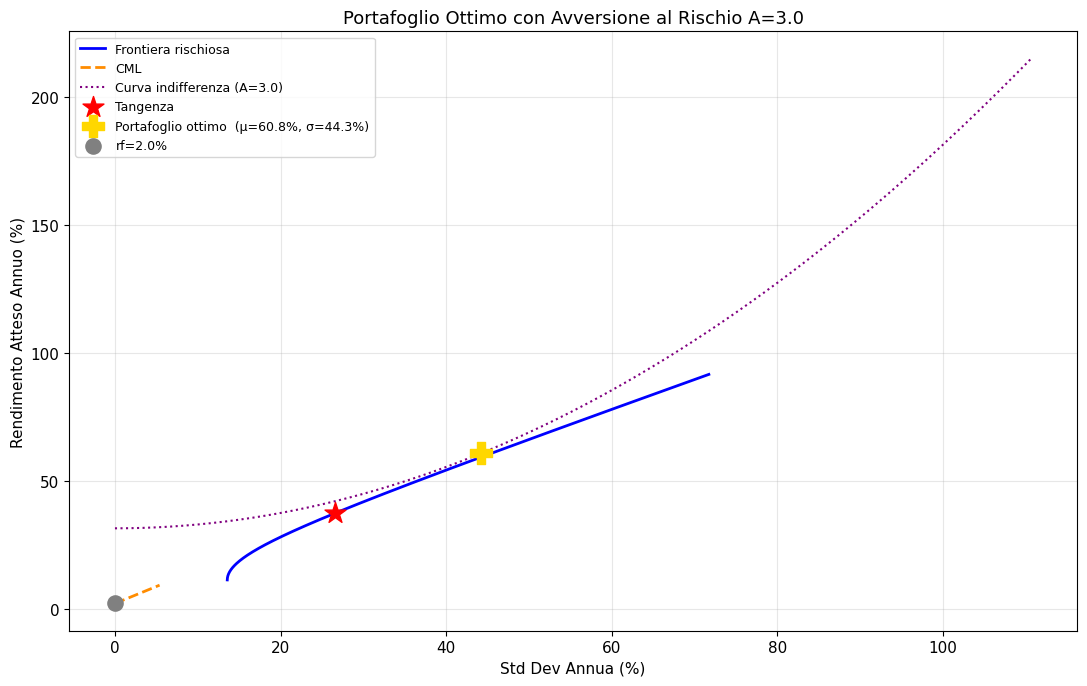

In [30]:
# ── Parametro avversione al rischio (modificabile) 
A_risk = 3.0  
# ── Frazione ottima nel portafoglio rischioso 
y_star = (mu_tan - rf) / (A_risk * sig_tan**2)
# Rendimento e rischio del portafoglio ottimo
mu_opt  = rf + y_star * (mu_tan - rf)
sig_opt = y_star * sig_tan
# Pesi nei singoli asset (la quota (1 - y_star) va al risk-free)
w_opt_risky = y_star * w_tan       # pesi negli asset rischiosi
w_rf        = 1 - y_star          # quota al risk-free
# Utilità raggiunta
U_opt = mu_opt - (A_risk / 2) * sig_opt**2

print(f"Avversione al rischio A = {A_risk}\n")
print(f"Frazione ottima nel portafoglio rischioso: y* = {y_star:.4f}")
if y_star > 1:
    print("  → y* > 1: l'investitore usa LEVA (prende a prestito al tasso rf)")
elif y_star < 0:
    print("  → y* < 0: l'investitore vende allo scoperto il portafoglio rischioso")
else:
    print("  → 0 < y* < 1: allocazione parziale tra rf e tangenza")

print(f"\nPortafoglio ottimo:")
print(f"  Rendimento atteso mensile  : {mu_opt*100:.4f}%  →  annuo: {mu_opt*ann*100:.2f}%")
print(f"  Std Dev mensile            : {sig_opt*100:.4f}%  →  annua: {sig_opt*np.sqrt(ann)*100:.2f}%")
print(f"  Utilità (mensile)          : {U_opt*100:.4f}%")
print(f"\n  Allocazione:")
print(f"    Risk-free (rf={rf_annual*100:.1f}%)  : {w_rf*100:.2f}%")
for t, w in zip(SELECTED, w_opt_risky):
    print(f"    {t:6s}                   : {w*100:.2f}%")
print(f"    Totale                   : {(w_rf + w_opt_risky.sum())*100:.2f}%")

# ── Grafico CML + indifferenza 
fig, ax = plt.subplots(figsize=(11, 7))

ax.plot(sig_analytical*np.sqrt(ann)*100, mu_grid*ann*100, 'b-', lw=2, label='Frontiera rischiosa')
ax.plot(sig_cml*np.sqrt(ann)*100, mu_cml*ann*100, 'darkorange', lw=2, ls='--', label='CML')

# Curva di indifferenza passante per il portafoglio ottimo
sig_indiff = np.linspace(0, sig_opt * 2.5, 200)
mu_indiff  = U_opt + (A_risk / 2) * sig_indiff**2
ax.plot(sig_indiff*np.sqrt(ann)*100, mu_indiff*ann*100,
        'purple', lw=1.5, ls=':', label=f'Curva indifferenza (A={A_risk})')

ax.scatter(sig_tan*np.sqrt(ann)*100, mu_tan*ann*100,
           color='red', s=250, marker='*', zorder=7, label='Tangenza')
ax.scatter(sig_opt*np.sqrt(ann)*100, mu_opt*ann*100,
           color='gold', s=250, marker='P', zorder=8,
           label=f'Portafoglio ottimo  (μ={mu_opt*ann*100:.1f}%, σ={sig_opt*np.sqrt(ann)*100:.1f}%)')
ax.scatter(0, rf_annual*100, color='grey', s=120, marker='o', zorder=6, label=f'rf={rf_annual*100:.1f}%')

ax.set_xlabel('Std Dev Annua (%)'); ax.set_ylabel('Rendimento Atteso Annuo (%)')
ax.set_title(f'Portafoglio Ottimo con Avversione al Rischio A={A_risk}', fontsize=13)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig('optimal_portfolio_A7.png', dpi=150)
plt.show()